# Forecasting Inflasi Bulanan

## Tujuan
Notebook ini membandingkan beberapa pendekatan forecasting untuk membaca arah inflasi bulanan Indonesia dan menyiapkan artefak model yang dipakai dashboard.

## Fokus kerja
- menjaga split waktu tetap kronologis
- membandingkan baseline tabular, LSTM, ARIMA, Prophet, dan ensemble
- menulis ulang artefak model dari jalur notebook yang eksplisit


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Data dan Validasi Awal

Dataset aktif berasal dari `clean_inflasi_ts.csv`. Pada tahap ini kita memastikan urutan waktu benar, kolom siap dipakai, dan tidak ada lubang data yang mengganggu eksperimen.


In [2]:
data_path = os.path.join('..', 'datasets', 'processed', 'clean_inflasi_ts.csv')
df = pd.read_csv(data_path)
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)
df.set_index('Tanggal', inplace=True)

# Drop kolom yang bukan numerik atau target leak
# Kita simpan semua fitur numerik yang tersedia
exclude_cols = ['Bulan', 'Tahun'] # Kita akan buat fitur siklikal nanti
feature_cols = [c for c in df.columns if c not in exclude_cols]

# Imputasi sisa NaN dengan ffill dan bfill (seharusnya sudah bersih)
df = df.ffill().bfill()

print(f"Shape data: {df.shape}")
print(f"Jumlah fitur: {len(feature_cols)}")
df.head()

Shape data: (257, 45)
Jumlah fitur: 43


,Inflasi_MoM,IHK,BI_Rate,Inflasi_Umum_MoM,Inflasi_Inti_MoM,Inflasi_HargaDiatur_MoM,Inflasi_Bergejolak_MoM,Harga_Minyak_USD,Brent_USD,DXY,...,CMO_Copper_USD,CMO_Aluminum_USD,CMO_IronOre_USD,CMO_NatGas_USD,CMO_NatGas_EU_USD,CMO_LNG_Japan_USD,Bulan,Tahun,Inflasi_YoY,Inflasi_YtD
Tanggal,,,,,,,,,,,,,,,,,,,,,
2005-01-01,1.43,118.53,7.32,-0.07,0.44,-2.67,0.79,42.97,76.395,83.1119,...,3145.45,1849.18,37.9,6.58,5.01,5.57,1,2005,17.033662,0.000000
2005-02-01,-0.17,118.33,7.15,-0.07,0.44,-2.67,0.79,44.82,76.395,83.7235,...,3170.00,1834.43,65.0,6.15,5.46,5.42,2,2005,17.033662,-0.168734
2005-03-01,1.91,120.59,8.81,-0.07,0.44,-2.67,0.79,50.94,76.395,82.8364,...,3253.70,1882.85,65.0,6.14,5.49,5.58,3,2005,17.033662,1.737957
2005-04-01,0.34,121.00,8.12,-0.07,0.44,-2.67,0.79,50.64,76.395,84.2671,...,3379.49,1979.85,65.0,6.97,5.52,5.59,4,2005,17.033662,2.083861
2005-05-01,0.21,121.25,7.40,-0.07,0.44,-2.67,0.79,47.83,76.395,85.6281,...,3394.48,1894.29,65.0,7.15,5.86,5.67,5,2005,17.033662,2.294778


## 2. Feature Engineering Lanjutan

Fitur tambahan di sini bertujuan membantu model membaca pola musiman dan interaksi antar-variabel eksternal.


In [3]:
# Fitur Siklikal Bulan
df['Bulan_Sin'] = np.sin(2 * np.pi * df['Bulan']/12)
df['Bulan_Cos'] = np.cos(2 * np.pi * df['Bulan']/12)

# Update feature list
feature_cols.extend(['Bulan_Sin', 'Bulan_Cos'])

# Fitur Interaksi Sederhana (Contoh)
if 'Harga_Minyak_USD' in df.columns and 'USD_IDR' in df.columns:
    df['Oil_x_USDIDR'] = df['Harga_Minyak_USD'] * df['USD_IDR']
    feature_cols.append('Oil_x_USDIDR')

print(f"Total fitur setelah engineering: {len(feature_cols)}")

Total fitur setelah engineering: 45


## 3. Lag Features dan Windowing

Karena target bersifat time series, kita membangun memori historis 12 bulan agar model punya konteks saat memprediksi bulan berikutnya.


In [4]:
lag_steps = 12

df_ml = df.copy()
tabular_features = []

# Buat Lag Features untuk SEMUA fitur (kecuali target nanti)
for feat in feature_cols:
    if feat == 'Inflasi_MoM': continue # Target
    for i in range(1, lag_steps + 1):
        col_name = f"{feat}_lag{i}"
        df_ml[col_name] = df_ml[feat].shift(i)
        tabular_features.append(col_name)

# Juga buat lag target (autoregressive)
for i in range(1, lag_steps + 1):
    col_name = f"Inflasi_MoM_lag{i}"
    df_ml[col_name] = df_ml['Inflasi_MoM'].shift(i)
    tabular_features.append(col_name)

# Drop baris NaN akibat shifting
df_ml.dropna(inplace=True)

X_tabular = df_ml[tabular_features].values
y_tabular = df_ml['Inflasi_MoM'].values
dates_tabular = df_ml.index

print(f"Shape Fitur Tabular: {X_tabular.shape}")

Shape Fitur Tabular: (245, 540)


## 4. Split Waktu

Pembagian train, validation, dan test dilakukan berdasarkan urutan waktu agar evaluasi tidak bocor ke masa lalu.


In [5]:
n = len(X_tabular)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X_tabular[:train_end], y_tabular[:train_end]
X_val, y_val = X_tabular[train_end:val_end], y_tabular[train_end:val_end]
X_test, y_test = X_tabular[val_end:], y_tabular[val_end:]

dates_test = dates_tabular[val_end:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (171, 540), Val: (37, 540), Test: (37, 540)


## 5. Ridge Regression

Ridge dipakai sebagai baseline tabular yang cepat dan stabil saat jumlah fitur lag menjadi besar.


In [6]:
# Ridge Regression lebih cocok untuk banyak fitur
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Ridge Regression -> MAE: {mae_ridge:.4f}, RMSE: {rmse_ridge:.4f}")

Ridge Regression -> MAE: 3.0508, RMSE: 3.5788


## 6. Random Forest

Random Forest membantu menguji apakah sinyal non-linear sederhana sudah cukup untuk mengalahkan baseline linear.


In [7]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest -> MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}")

Random Forest -> MAE: 0.4576, RMSE: 0.5769


## 7. Gradient Boosting

Gradient Boosting dipakai sebagai baseline tabular yang lebih agresif dalam menangkap pola non-linear dan interaksi antar-lag.


In [8]:
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"Gradient Boosting -> MAE: {mae_gb:.4f}, RMSE: {rmse_gb:.4f}")

Gradient Boosting -> MAE: 0.4372, RMSE: 0.5505


## 8. LSTM

LSTM dipakai untuk membaca urutan waktu secara langsung dari jendela fitur bulanan, dengan early stopping untuk menjaga training tetap waras.


In [9]:
# Siapkan Data untuk LSTM
lstm_features = ['Inflasi_MoM'] + [c for c in df.columns if c not in ['Inflasi_MoM', 'Bulan', 'Tahun']]
df_lstm = df[lstm_features].copy()

# Scaling (Target terpisah agar inverse mudah)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit scaler HANYA pada data train (hindari leakage)
# Train limit termasuk lag awal agar sequence valid
train_limit_idx = df_lstm.index[train_end]

X_all = df_lstm.drop('Inflasi_MoM', axis=1).values
y_all = df_lstm['Inflasi_MoM'].values.reshape(-1, 1)

# Scaler fit pada 70% data pertama
scaler_X.fit(X_all[:train_end])
scaler_y.fit(y_all[:train_end])

X_scaled = scaler_X.transform(X_all)
y_scaled = scaler_y.transform(y_all)

def create_lstm_sequences(X, y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(xs), np.array(ys)

X_seq, y_seq = create_lstm_sequences(X_scaled, y_scaled, lag_steps)

# Split sesuai indeks waktu
X_train_lstm = torch.tensor(X_seq[:train_end], dtype=torch.float32).to(device)
y_train_lstm = torch.tensor(y_seq[:train_end], dtype=torch.float32).to(device)

X_val_lstm = torch.tensor(X_seq[train_end:val_end], dtype=torch.float32).to(device)
y_val_lstm = torch.tensor(y_seq[train_end:val_end], dtype=torch.float32).to(device)

X_test_lstm = torch.tensor(X_seq[val_end:], dtype=torch.float32).to(device)
y_test_lstm = torch.tensor(y_seq[val_end:], dtype=torch.float32).to(device)

input_size = X_train_lstm.shape[2]
print(f"LSTM Input Size: {input_size} fitur")

LSTM Input Size: 44 fitur


In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.norm(out[:, -1, :])
        out = self.fc(out)
        return out

hidden_size = 128
num_layers = 2
lstm_model = LSTMModel(input_size, hidden_size, num_layers, 1).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Training Loop dengan Early Stopping
epochs = 200
patience = 30
best_val_loss = float('inf')
counter = 0
best_model_state = None

for epoch in range(epochs):
    lstm_model.train()
    optimizer.zero_grad()
    outputs = lstm_model(X_train_lstm)
    loss = criterion(outputs, y_train_lstm)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
    optimizer.step()
    
    # Validation
    lstm_model.eval()
    with torch.no_grad():
        val_outputs = lstm_model(X_val_lstm)
        val_loss = criterion(val_outputs, y_val_lstm)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = lstm_model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
            
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}")

# Load best model
lstm_model.load_state_dict(best_model_state)

Epoch 50: Train Loss: 0.002910, Val Loss: 0.001193
Early stopping at epoch 75


<All keys matched successfully>

In [11]:
lstm_model.eval()
with torch.no_grad():
    y_pred_lstm_scaled = lstm_model(X_test_lstm).cpu().numpy()

# Inverse transform
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_lstm.cpu().numpy())

mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))

print(f"LSTM Advanced -> MAE: {mae_lstm:.4f}, RMSE: {rmse_lstm:.4f}")

LSTM Advanced -> MAE: 0.3888, RMSE: 0.4905


## 9. ARIMA

ARIMA memberi baseline statistik klasik yang tetap penting sebagai pembanding model machine learning.

- AR: memakai pola masa lalu
- I: menangani differencing bila perlu
- MA: memakai struktur error masa lalu


In [12]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from itertools import product
import pickle
print('statsmodels loaded')

statsmodels loaded


In [13]:
ts_arima = df_ml['Inflasi_MoM'].dropna()

print('=' * 50)
print('UJI STACIONERITAS (Augmented Dickey-Fuller)')
print('=' * 50)

d_order = 0
for d_test in range(3):
    data = ts_arima if d_test == 0 else ts_arima.diff(d_test).dropna()
    result = adfuller(data)
    p_val = result[1]
    status = 'STATIONER' if p_val <= 0.05 else 'Belum stationer'
    label = 'Original' if d_test == 0 else f'Differenced (d={d_test})'
    print(f'{label}: ADF={result[0]:.4f}, p={p_val:.6f} -> {status}')
    if p_val <= 0.05:
        d_order = d_test
        print(f'Rekomendasi d = {d_order}')
        break
else:
    d_order = 2
    print(f'Gunakan d = {d_order}')

UJI STACIONERITAS (Augmented Dickey-Fuller)
Original: ADF=-3.2196, p=0.018880 -> STATIONER
Rekomendasi d = 0


In [14]:
p_range = range(0, 5)
q_range = range(0, 5)

split_arima = int(len(ts_arima) * 0.8)
train_arima = ts_arima.iloc[:split_arima]
test_arima = ts_arima.iloc[split_arima:]

print(f'Train: {len(train_arima)} obs | Test: {len(test_arima)} obs')
print(f'Grid Search ARIMA(p,{d_order},q)...')

results_arima = []
best_aic = float('inf')
best_order_arima = (1, d_order, 1)

for p, q in product(p_range, q_range):
    try:
        model = ARIMA(train_arima, order=(p, d_order, q))
        fitted = model.fit()
        pred = fitted.forecast(steps=len(test_arima))
        mae_val = mean_absolute_error(test_arima, pred)
        rmse_val = np.sqrt(mean_squared_error(test_arima, pred))
        results_arima.append({'order': (p, d_order, q), 'aic': fitted.aic, 'mae': mae_val, 'rmse': rmse_val})
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order_arima = (p, d_order, q)
    except Exception:
        continue

results_arima.sort(key=lambda x: x['aic'])
print(f'\nTop 5 ARIMA Models:')
for r in results_arima[:5]:
    print(f"  ARIMA{r['order']}: AIC={r['aic']:.2f} MAE={r['mae']:.4f} RMSE={r['rmse']:.4f}")
print(f'\nBest: ARIMA{best_order_arima} (AIC={best_aic:.2f})')

Train: 196 obs | Test: 49 obs
Grid Search ARIMA(p,0,q)...


C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\Local


Top 5 ARIMA Models:
  ARIMA(3, 0, 3): AIC=209.11 MAE=0.3381 RMSE=0.4420
  ARIMA(2, 0, 3): AIC=209.18 MAE=0.3369 RMSE=0.4440
  ARIMA(3, 0, 4): AIC=209.47 MAE=0.3388 RMSE=0.4460
  ARIMA(2, 0, 4): AIC=209.59 MAE=0.3381 RMSE=0.4412
  ARIMA(3, 0, 2): AIC=210.33 MAE=0.3386 RMSE=0.4419

Best: ARIMA(3, 0, 3) (AIC=209.11)


C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
final_arima = ARIMA(ts_arima, order=best_order_arima)
final_arima_fitted = final_arima.fit()

pred_ins = final_arima_fitted.fittedvalues
mae_arima = mean_absolute_error(ts_arima.iloc[1:], pred_ins.iloc[1:])
rmse_arima = np.sqrt(mean_squared_error(ts_arima.iloc[1:], pred_ins.iloc[1:]))

print(final_arima_fitted.summary())
print(f'\nIn-sample MAE: {mae_arima:.4f}')
print(f'In-sample RMSE: {rmse_arima:.4f}')

C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            Inflasi_MoM   No. Observations:                  245
Model:                 ARIMA(3, 0, 3)   Log Likelihood                -129.658
Date:                Mon, 15 Jun 2026   AIC                            275.315
Time:                        10:26:07   BIC                            303.325
Sample:                    01-01-2006   HQIC                           286.595
                         - 05-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3746      0.049      7.636      0.000       0.278       0.471
ar.L1          1.1559      0.129      8.971      0.000       0.903       1.408
ar.L2         -1.1231      0.119     -9.432      0.0

C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Forecast ARIMA 3 Bulan:
  Jun 2026: 0.2501% (95% CI: [-0.5520%, 1.0522%])
  Jul 2026: 0.2843% (95% CI: [-0.5989%, 1.1675%])
  Aug 2026: 0.4240% (95% CI: [-0.4597%, 1.3076%])


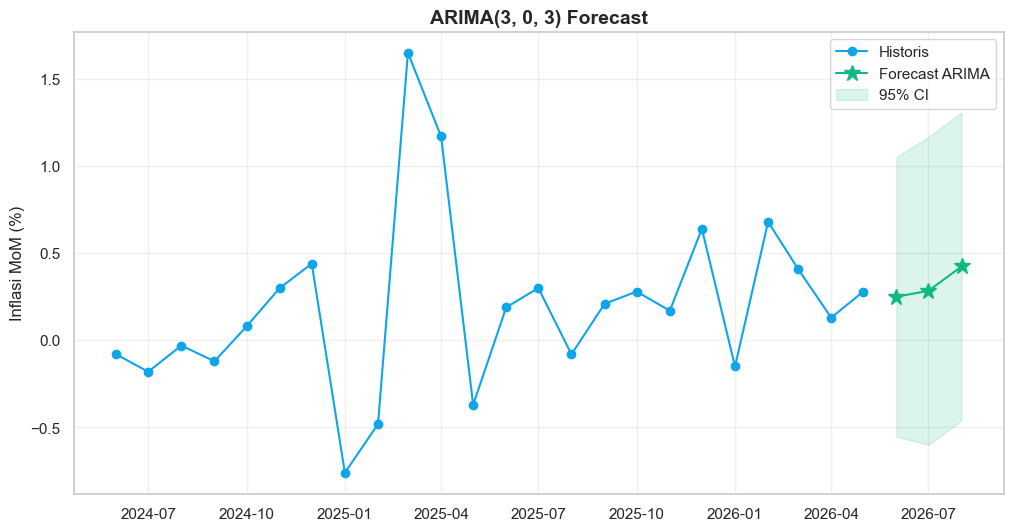

Model saved: models/arima_inflasi.pkl
Forecast saved: models/arima_forecast.pkl


In [16]:
forecast_arima = final_arima_fitted.get_forecast(steps=3)
fc_mean = forecast_arima.predicted_mean
fc_ci = forecast_arima.conf_int(alpha=0.05)
fc_dates = pd.date_range(start=ts_arima.index[-1], periods=4, freq='MS')[1:]

print('Forecast ARIMA 3 Bulan:')
for i in range(3):
    d = fc_dates[i].strftime('%b %Y')
    m = fc_mean.iloc[i]
    lo = fc_ci.iloc[i, 0]
    hi = fc_ci.iloc[i, 1]
    print(f'  {d}: {m:.4f}% (95% CI: [{lo:.4f}%, {hi:.4f}%])')

plt.figure(figsize=(12, 6))
recent = ts_arima.last('24M')
plt.plot(recent.index, recent.values, label='Historis', marker='o', color='#0EA5E9')
plt.plot(fc_dates, fc_mean.values, label='Forecast ARIMA', marker='*', color='#10B981', markersize=12)
plt.fill_between(fc_dates, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], alpha=0.15, color='#10B981', label='95% CI')
plt.title(f'ARIMA{best_order_arima} Forecast', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylabel('Inflasi MoM (%)')
plt.show()

os.makedirs('../models', exist_ok=True)
with open('../models/arima_inflasi.pkl', 'wb') as f:
    pickle.dump(final_arima_fitted, f)
with open('../models/arima_forecast.pkl', 'wb') as f:
    pickle.dump({
        'forecast': {'forecast_mean': fc_mean.tolist(), 'forecast_lower': fc_ci.iloc[:, 0].tolist(), 'forecast_upper': fc_ci.iloc[:, 1].tolist()},
        'order': best_order_arima,
        'last_date': ts_arima.index[-1].strftime('%Y-%m-%d'),
        'last_value': float(ts_arima.iloc[-1])
    }, f)
print(f'Model saved: models/arima_inflasi.pkl')
print(f'Forecast saved: models/arima_forecast.pkl')

## 10. Prophet

Prophet dipakai sebagai pembanding time series yang lebih fleksibel terhadap tren dan seasonality, sambil tetap relatif mudah dijelaskan ke audiens non-ML berat.


In [17]:
from prophet import Prophet

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.abs(y_true) + np.abs(y_pred)
    valid = denominator > 1e-8
    if not np.any(valid):
        return 0.0
    return float(np.mean(2.0 * np.abs(y_pred[valid] - y_true[valid]) / denominator[valid]) * 100)

common_test_dates = pd.DatetimeIndex(dates_test)
common_actual = np.asarray(y_test, dtype=float).reshape(-1)
common_train_series = df.loc[df.index < common_test_dates[0], 'Inflasi_MoM'].copy()

prophet_df = df.reset_index()[['Tanggal', 'Inflasi_MoM']].rename(columns={'Tanggal': 'ds', 'Inflasi_MoM': 'y'})
prophet_train = prophet_df[prophet_df['ds'] < common_test_dates[0]].copy()
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode='additive')
prophet_model.fit(prophet_train)

prophet_test_pred = prophet_model.predict(pd.DataFrame({'ds': common_test_dates}))['yhat'].to_numpy()
mae_prophet = mean_absolute_error(common_actual, prophet_test_pred)
rmse_prophet = np.sqrt(mean_squared_error(common_actual, prophet_test_pred))
print(f"Prophet -> MAE: {mae_prophet:.4f}, RMSE: {rmse_prophet:.4f}")

future_steps = 3
future_dates = pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(1), periods=future_steps, freq='MS')
prophet_future_pred = prophet_model.predict(pd.DataFrame({'ds': future_dates}))['yhat'].to_numpy()
print('Forecast Prophet 3 Bulan:')
for ds, val in zip(future_dates, prophet_future_pred):
    print(f"  {ds.strftime('%b %Y')}: {val:.4f}%")


10:26:12 - cmdstanpy - INFO - Chain [1] start processing
10:26:40 - cmdstanpy - INFO - Chain [1] done processing


Prophet -> MAE: 0.3865, RMSE: 0.5355
Forecast Prophet 3 Bulan:
  Jun 2026: 0.1486%
  Jul 2026: 0.3654%
  Aug 2026: 0.0047%


## 11. Ensemble Forecast

Ensemble menggabungkan model yang paling relevan untuk horizon waktu: LSTM, ARIMA, dan Prophet. Bobot dihitung dari inverse MAE pada horizon uji yang sama, supaya model yang lebih presisi mendapat kontribusi lebih besar.


In [18]:
lstm_test_pred = np.asarray(y_pred_lstm, dtype=float).reshape(-1)
naive_test_pred = df_ml.loc[common_test_dates, 'Inflasi_MoM_lag1'].astype(float).to_numpy()

arima_compare_fitted = ARIMA(common_train_series, order=best_order_arima).fit()
arima_test_pred = np.asarray(arima_compare_fitted.forecast(steps=len(common_test_dates)), dtype=float).reshape(-1)

metric_rows = {
    'naive': naive_test_pred,
    'arima': arima_test_pred,
    'lstm': lstm_test_pred,
    'prophet': np.asarray(prophet_test_pred, dtype=float).reshape(-1),
}

comparison_metrics = {}
for name, preds in metric_rows.items():
    comparison_metrics[name] = {
        'model': name,
        'n_test': int(len(common_actual)),
        'mae': float(mean_absolute_error(common_actual, preds)),
        'rmse': float(np.sqrt(mean_squared_error(common_actual, preds))),
        'smape': float(smape(common_actual, preds)),
        'predictions': [float(v) for v in preds],
        'actuals': [float(v) for v in common_actual],
    }

raw_weights = {k: 1.0 / max(comparison_metrics[k]['mae'], 1e-6) for k in ['lstm', 'arima', 'prophet']}
weight_sum = sum(raw_weights.values())
weights = {k: float(v / weight_sum) for k, v in raw_weights.items()}
ensemble_test_pred = (
    weights['lstm'] * metric_rows['lstm'] +
    weights['arima'] * metric_rows['arima'] +
    weights['prophet'] * metric_rows['prophet']
)
comparison_metrics['ensemble'] = {
    'model': 'ensemble',
    'n_test': int(len(common_actual)),
    'mae': float(mean_absolute_error(common_actual, ensemble_test_pred)),
    'rmse': float(np.sqrt(mean_squared_error(common_actual, ensemble_test_pred))),
    'smape': float(smape(common_actual, ensemble_test_pred)),
    'predictions': [float(v) for v in ensemble_test_pred],
    'actuals': [float(v) for v in common_actual],
}

print('Weights ensemble:', {k: round(v, 3) for k, v in weights.items()})
print(f"Ensemble -> MAE: {comparison_metrics['ensemble']['mae']:.4f}, RMSE: {comparison_metrics['ensemble']['rmse']:.4f}, sMAPE: {comparison_metrics['ensemble']['smape']:.2f}%")


C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\adief\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\Local

Weights ensemble: {'lstm': 0.314, 'arima': 0.37, 'prophet': 0.316}
Ensemble -> MAE: 0.3292, RMSE: 0.4499, sMAPE: 105.62%


## 12. Ringkasan Perbandingan Model

Setelah semua model siap, bagian ini merangkum performa pada horizon uji yang sama agar pembacaan trade-off lebih adil.


               Model       MAE      RMSE       sMAPE
0           Ensemble  0.329183  0.449858  105.619183
1              ARIMA  0.329862  0.445275  100.401662
2            Prophet  0.386524  0.535468  138.911421
3               LSTM  0.388752  0.490518  107.443292
4  Gradient Boosting  0.437247  0.550474         NaN
5      Random Forest  0.457618  0.576911         NaN
6              Ridge  3.050823  3.578788         NaN


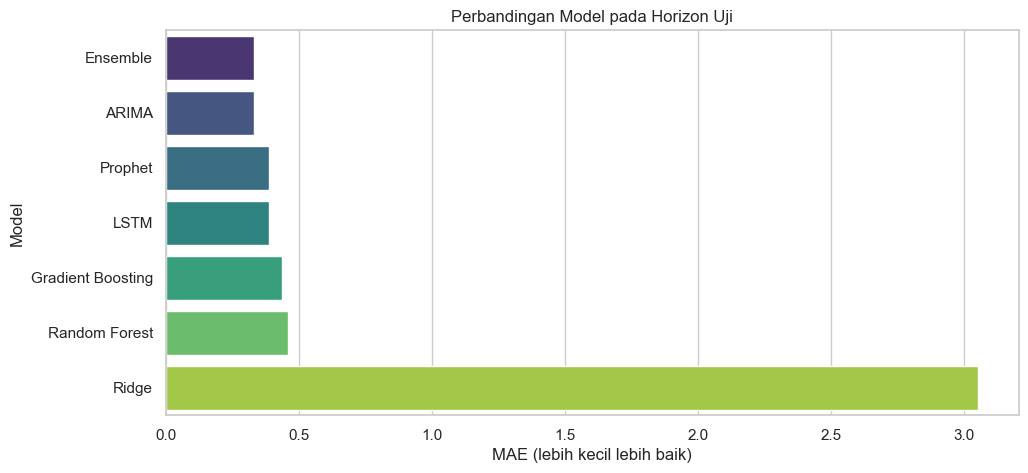

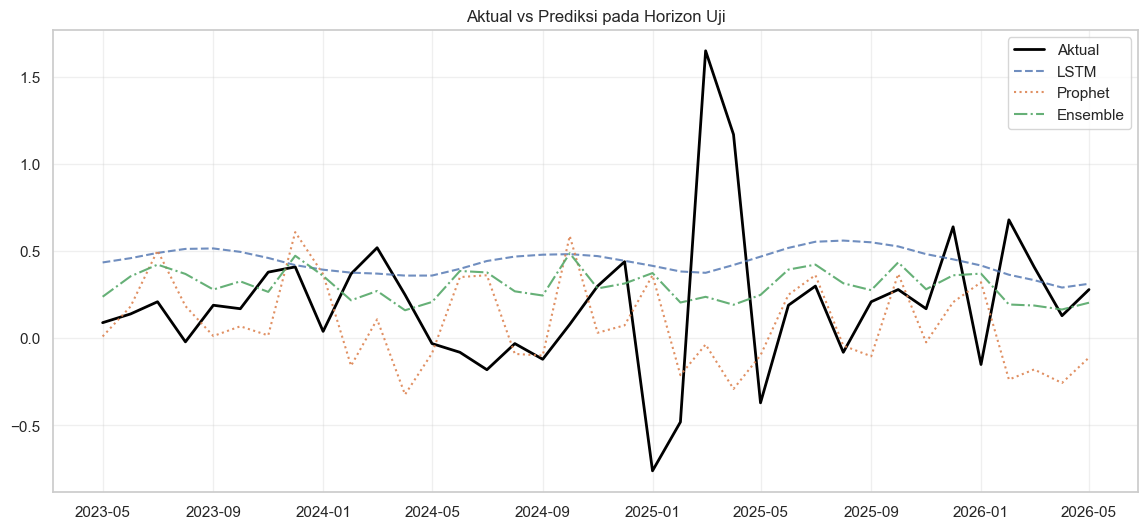

In [19]:
models = ['Ridge', 'Random Forest', 'Gradient Boosting', 'LSTM', 'ARIMA', 'Prophet', 'Ensemble']
mae_scores = [
    mae_ridge,
    mae_rf,
    mae_gb,
    comparison_metrics['lstm']['mae'],
    comparison_metrics['arima']['mae'],
    comparison_metrics['prophet']['mae'],
    comparison_metrics['ensemble']['mae'],
]
rmse_scores = [
    rmse_ridge,
    rmse_rf,
    rmse_gb,
    comparison_metrics['lstm']['rmse'],
    comparison_metrics['arima']['rmse'],
    comparison_metrics['prophet']['rmse'],
    comparison_metrics['ensemble']['rmse'],
]
smape_scores = [
    None,
    None,
    None,
    comparison_metrics['lstm']['smape'],
    comparison_metrics['arima']['smape'],
    comparison_metrics['prophet']['smape'],
    comparison_metrics['ensemble']['smape'],
]

eval_df = pd.DataFrame({'Model': models, 'MAE': mae_scores, 'RMSE': rmse_scores, 'sMAPE': smape_scores})
eval_df = eval_df.sort_values('MAE').reset_index(drop=True)
print(eval_df)

plt.figure(figsize=(11, 5))
sns.barplot(x='MAE', y='Model', data=eval_df, palette='viridis')
plt.title('Perbandingan Model pada Horizon Uji')
plt.xlabel('MAE (lebih kecil lebih baik)')
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(dates_test, common_actual, label='Aktual', color='black', linewidth=2)
plt.plot(dates_test, np.asarray(metric_rows['lstm']).reshape(-1), label='LSTM', linestyle='--', alpha=0.8)
plt.plot(dates_test, np.asarray(metric_rows['prophet']).reshape(-1), label='Prophet', linestyle=':', alpha=0.9)
plt.plot(dates_test, np.asarray(ensemble_test_pred).reshape(-1), label='Ensemble', linestyle='-.', alpha=0.9)
plt.title('Aktual vs Prediksi pada Horizon Uji')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 13. Forecast Horizon Berikutnya

Forecast masa depan dibuat dinamis mengikuti tanggal terakhir pada dataset, sehingga notebook tidak lagi terpaku pada nama bulan yang sudah usang.


Prediksi LSTM June 2026: 0.36%
Prediksi LSTM July 2026: 0.39%
Prediksi LSTM August 2026: 0.41%


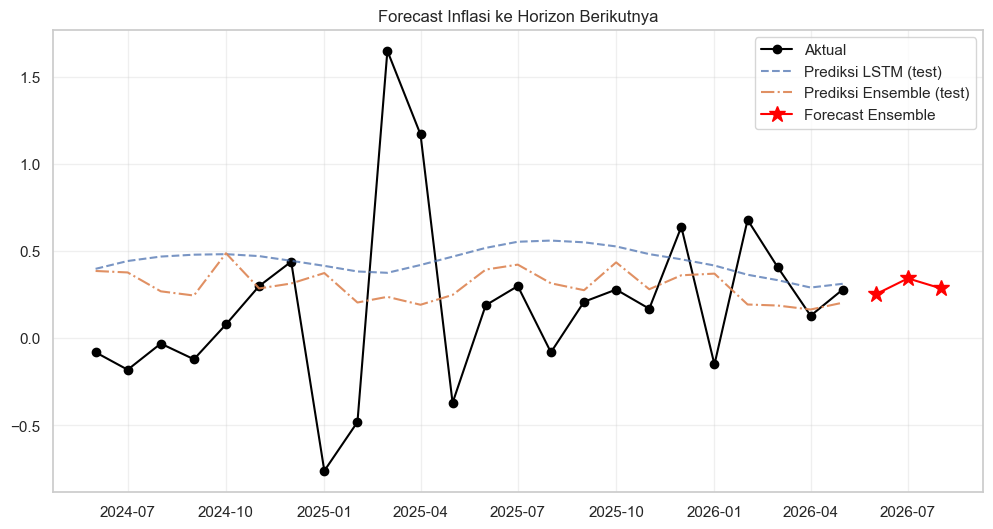

In [20]:
# Forecast multi-model ke horizon berikutnya
future_steps = 3
future_dates = pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(1), periods=future_steps, freq='MS')

# LSTM future forecast: input exogenous digeser dan dibawa flat dari observasi terakhir
last_sequence = X_scaled[-lag_steps:]
current_seq = torch.tensor(np.array([last_sequence]), dtype=torch.float32).to(device)
lstm_future_preds = []

lstm_model.eval()
with torch.no_grad():
    for future_date in future_dates:
        pred_scaled = lstm_model(current_seq).cpu().numpy()
        pred_real = scaler_y.inverse_transform(pred_scaled)[0][0]
        lstm_future_preds.append(float(pred_real))
        print(f"Prediksi LSTM {future_date.strftime('%B %Y')}: {pred_real:.2f}%")

        next_exogenous = current_seq[0, -1, :].detach().cpu().numpy().copy()
        rolled = np.vstack([current_seq[0, 1:, :].detach().cpu().numpy(), next_exogenous])
        current_seq = torch.tensor(np.array([rolled]), dtype=torch.float32).to(device)

arima_future_preds = [float(v) for v in np.array(fc_mean).reshape(-1)]
prophet_future_preds = [float(v) for v in np.array(prophet_future_pred).reshape(-1)]
ensemble_future_preds = [
    float(weights['lstm'] * l + weights['arima'] * a + weights['prophet'] * p)
    for l, a, p in zip(lstm_future_preds, arima_future_preds, prophet_future_preds)
]

forecast_data = {
    'labels': [d.strftime('%b %Y') for d in dates_test[-12:]] + [d.strftime('%b %Y') for d in future_dates],
    'actual': list(np.array(y_test).reshape(-1)[-12:]) + [None] * future_steps,
    'pred_lstm': list(np.array(lstm_test_pred).reshape(-1)[-12:]) + lstm_future_preds,
    'pred_ensemble': list(np.array(ensemble_test_pred).reshape(-1)[-12:]) + ensemble_future_preds,
}

plt.figure(figsize=(12, 6))
plt.plot(dates_test[-24:], np.array(y_test).reshape(-1)[-24:], label='Aktual', marker='o', color='black')
plt.plot(dates_test[-24:], np.array(lstm_test_pred).reshape(-1)[-24:], label='Prediksi LSTM (test)', linestyle='--', alpha=0.75)
plt.plot(dates_test[-24:], np.array(ensemble_test_pred).reshape(-1)[-24:], label='Prediksi Ensemble (test)', linestyle='-.', alpha=0.9)
plt.plot(future_dates, ensemble_future_preds, label='Forecast Ensemble', marker='*', color='red', markersize=12)
plt.title('Forecast Inflasi ke Horizon Berikutnya')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 14. Export Artefak Dashboard

Bagian ini menulis ulang artefak model yang dipakai dashboard dari hasil notebook saat ini, sehingga jalur retrain menjadi lebih transparan dan profesional.


In [21]:
import json
import pickle
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

torch.save({
    'model_state_dict': lstm_model.state_dict(),
    'input_size': input_size,
    'seq_length': lag_steps,
    'feature_columns': lstm_features,
}, models_dir / 'lstm_model.pt')
with open(models_dir / 'lstm_scaler_x.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
with open(models_dir / 'lstm_scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)

with open(models_dir / 'arima_inflasi.pkl', 'wb') as f:
    pickle.dump(final_arima_fitted, f)
with open(models_dir / 'arima_forecast.pkl', 'wb') as f:
    pickle.dump({
        'forecast': {
            'forecast_mean': arima_future_preds,
            'forecast_lower': fc_ci.iloc[:, 0].tolist(),
            'forecast_upper': fc_ci.iloc[:, 1].tolist(),
        },
        'order': best_order_arima,
        'last_date': ts_arima.index[-1].strftime('%Y-%m-%d'),
        'last_value': float(ts_arima.iloc[-1]),
        'metrics': {
            'aic': float(final_arima_fitted.aic),
            'bic': float(final_arima_fitted.bic),
            'test_mae': float(comparison_metrics['arima']['mae']),
            'test_rmse': float(comparison_metrics['arima']['rmse']),
            'test_smape': float(comparison_metrics['arima']['smape']),
        },
    }, f)

with open(models_dir / 'arima_metrics.pkl', 'wb') as f:
    pickle.dump({
        'order': best_order_arima,
        'aic': float(final_arima_fitted.aic),
        'bic': float(final_arima_fitted.bic),
        'mae': float(comparison_metrics['arima']['mae']),
        'rmse': float(comparison_metrics['arima']['rmse']),
        'smape': float(comparison_metrics['arima']['smape']),
        'mape': None,
        'note': 'Artefak ARIMA ditulis dari notebook forecasting_inflasi_models.ipynb',
    }, f)

with open(models_dir / 'ensemble_forecast.pkl', 'wb') as f:
    pickle.dump({
        'weights': weights,
        'lstm_forecast': lstm_future_preds,
        'arima_forecast': arima_future_preds,
        'prophet_forecast': prophet_future_preds,
        'ensemble_forecast': ensemble_future_preds,
        'last_date': df.index[-1].strftime('%Y-%m-%d'),
        'last_value': float(df['Inflasi_MoM'].iloc[-1]),
        'n_train': int(len(common_train_series)),
    }, f)

with open(models_dir / 'ensemble_metrics.pkl', 'wb') as f:
    pickle.dump({
        **comparison_metrics,
        'weights': weights,
        'improvement_pct': float(((comparison_metrics['naive']['mae'] - comparison_metrics['ensemble']['mae']) / comparison_metrics['naive']['mae']) * 100),
    }, f)

forecast_payload = {
    'dates_test': [d.strftime('%Y-%m-%d') for d in dates_test],
    'actual_test': [float(v) for v in np.array(y_test).reshape(-1)],
    'lstm_test_pred': [float(v) for v in np.array(lstm_test_pred).reshape(-1)],
    'arima_test_pred': [float(v) for v in np.array(arima_test_pred).reshape(-1)],
    'prophet_test_pred': [float(v) for v in np.array(prophet_test_pred).reshape(-1)],
    'ensemble_test_pred': [float(v) for v in np.array(ensemble_test_pred).reshape(-1)],
    'future_dates': [d.strftime('%Y-%m-%d') for d in future_dates],
    'future_lstm_pred': lstm_future_preds,
    'future_arima_pred': arima_future_preds,
    'future_prophet_pred': prophet_future_preds,
    'future_ensemble_pred': ensemble_future_preds,
    'evaluation_table': eval_df.to_dict(orient='records'),
}
with open(models_dir / 'forecast_results.json', 'w', encoding='utf-8') as f:
    json.dump(forecast_payload, f, ensure_ascii=False, indent=2)

print('Saved: ../models/lstm_model.pt')
print('Saved: ../models/lstm_scaler_x.pkl')
print('Saved: ../models/lstm_scaler_y.pkl')
print('Saved: ../models/arima_inflasi.pkl')
print('Saved: ../models/arima_forecast.pkl')
print('Saved: ../models/arima_metrics.pkl')
print('Saved: ../models/ensemble_forecast.pkl')
print('Saved: ../models/ensemble_metrics.pkl')
print('Saved: ../models/forecast_results.json')


Saved: ../models/lstm_model.pt
Saved: ../models/lstm_scaler_x.pkl
Saved: ../models/lstm_scaler_y.pkl
Saved: ../models/arima_inflasi.pkl
Saved: ../models/arima_forecast.pkl
Saved: ../models/arima_metrics.pkl
Saved: ../models/ensemble_forecast.pkl
Saved: ../models/ensemble_metrics.pkl
Saved: ../models/forecast_results.json
